# 机器学习分类预测分析 - 完整工作流

## 项目背景
本Notebook演示了完整的机器学习数据分析流程，使用二分类数据集预测目标变量Y。

## 分析流程
1. 数据加载与概览
2. 数据清洗与预处理
3. 探索性数据分析(EDA)
4. 特征工程
5. 模型训练与评估
6. 结果可视化与解释

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
font_path = '/System/Library/Fonts/STHeiti Medium.ttc'
plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

# 设置绘图样式
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 导入机器学习库
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, 
    roc_curve
)

print("✅ 库导入成功！")

✅ 库导入成功！


## 1. 数据加载与概览

In [2]:
# 加载数据
df = pd.read_csv('3.3.预测型分析 - 机器学习.csv', encoding='utf-8-sig')

# 基础信息
print("="*60)
print("数据概览")
print("="*60)
print(f"\n数据形状: {df.shape[0]} 行 × {df.shape[1]} 列")
print(f"\n列名: {list(df.columns)}")
print(f"\n数据类型:")
print(df.dtypes)

数据概览

数据形状: 4050 行 × 8 列

列名: ['p1', 'p2', 'gender', 'family', 'realty_ind', 'age', 'p3_f', 'Y']

数据类型:
p1             int64
p2             int64
gender        object
family        object
realty_ind     int64
age            int64
p3_f           int64
Y              int64
dtype: object


In [3]:
# 查看前几行数据
print("\n数据预览（前10行）:")
df.head(10)


数据预览（前10行）:


,p1,p2,gender,family,realty_ind,age,p3_f,Y
0,0,1,F,Married,1,57,6,0
1,1,1,M,Married,1,42,18,1
2,0,1,F,Married,1,65,12,0
3,0,1,M,Civil marriage,1,56,6,1
4,1,1,M,Single / not married,1,39,18,1
5,0,1,F,Married,1,47,6,0
6,0,1,M,Single / not married,1,41,0,1
7,0,1,F,Married,1,31,18,1
8,1,1,F,Married,1,55,24,1
9,0,1,F,Civil marriage,1,66,6,0


In [4]:
# 数据质量检查
print("\n" + "="*60)
print("数据质量检查")
print("="*60)

# 缺失值统计
missing = df.isnull().sum()
print(f"\n缺失值统计:")
print(missing[missing > 0] if missing.sum() > 0 else "无缺失值")

# 重复值检查
duplicates = df.duplicated().sum()
print(f"\n重复行数: {duplicates}")

# 目标变量分布
print(f"\n目标变量Y分布:")
print(df['Y'].value_counts())
print(f"\n目标变量比例:")
print(df['Y'].value_counts(normalize=True).round(4))


数据质量检查

缺失值统计:
无缺失值

重复行数: 1732

目标变量Y分布:
Y
0    2762
1    1288
Name: count, dtype: int64

目标变量比例:
Y
0    0.682
1    0.318
Name: proportion, dtype: float64


## 2. 探索性数据分析(EDA)

In [5]:
# 数值型变量描述统计
print("数值型变量描述统计:")
df.describe()

数值型变量描述统计:


,p1,p2,realty_ind,age,p3_f,Y
count,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000
mean,0.114074,0.971852,0.688889,43.626173,7.506173,0.318025
std,0.317940,0.165416,0.463005,11.396685,6.408972,0.465767
min,0.000000,0.000000,0.000000,22.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,34.000000,4.000000,0.000000
50%,0.000000,1.000000,1.000000,43.000000,6.000000,0.000000
75%,0.000000,1.000000,1.000000,53.000000,12.000000,1.000000
max,1.000000,1.000000,1.000000,68.000000,30.000000,1.000000


In [6]:
# 类别型变量统计
print("\n类别型变量统计:")
categorical_cols = ['gender', 'family']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))


类别型变量统计:

gender:
gender
F    2663
M    1387
Name: count, dtype: int64

family:
family
Married                 2750
Single / not married     544
Civil marriage           355
Separated                237
Widow                    164
Name: count, dtype: int64


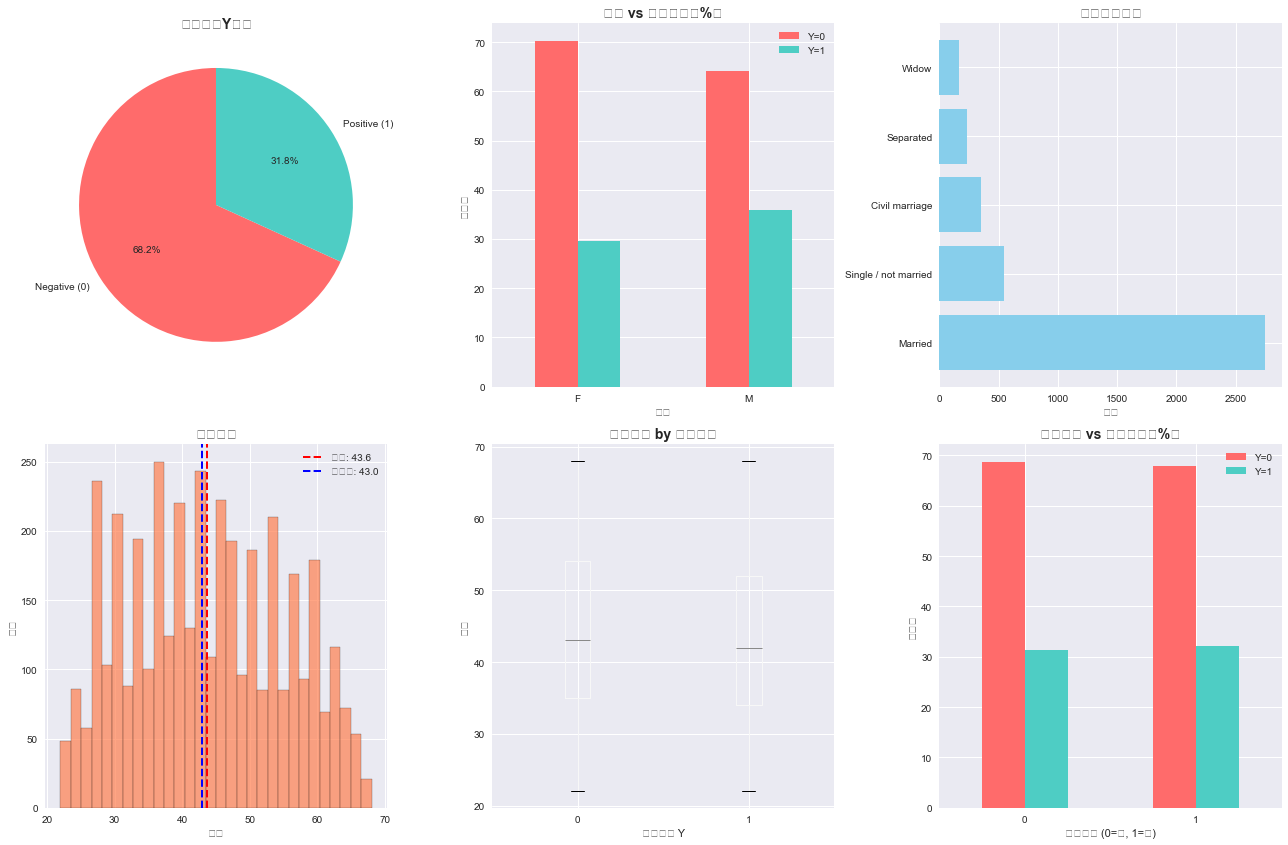

✅ EDA可视化已生成


In [7]:
# 创建综合可视化图
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 目标变量分布
ax1 = axes[0, 0]
y_counts = df['Y'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
ax1.pie(y_counts, labels=['Negative (0)', 'Positive (1)'], autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title('目标变量Y分布', fontsize=14, fontweight='bold')

# 2. 性别分布与目标变量关系
ax2 = axes[0, 1]
gender_y = pd.crosstab(df['gender'], df['Y'], normalize='index') * 100
gender_y.plot(kind='bar', ax=ax2, color=colors)
ax2.set_title('性别 vs 目标变量（%）', fontsize=14, fontweight='bold')
ax2.set_xlabel('性别')
ax2.set_ylabel('百分比')
ax2.legend(['Y=0', 'Y=1'])
ax2.tick_params(axis='x', rotation=0)

# 3. 家庭状态分布
ax3 = axes[0, 2]
family_counts = df['family'].value_counts()
ax3.barh(family_counts.index, family_counts.values, color='skyblue')
ax3.set_title('家庭状态分布', fontsize=14, fontweight='bold')
ax3.set_xlabel('数量')

# 4. 年龄分布
ax4 = axes[1, 0]
ax4.hist(df['age'], bins=30, color='coral', edgecolor='black', alpha=0.7)
ax4.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'均值: {df["age"].mean():.1f}')
ax4.axvline(df['age'].median(), color='blue', linestyle='--', linewidth=2, label=f'中位数: {df["age"].median():.1f}')
ax4.set_title('年龄分布', fontsize=14, fontweight='bold')
ax4.set_xlabel('年龄')
ax4.set_ylabel('频数')
ax4.legend()

# 5. 年龄 vs 目标变量
ax5 = axes[1, 1]
df.boxplot(column='age', by='Y', ax=ax5)
ax5.set_title('年龄分布 by 目标变量', fontsize=14, fontweight='bold')
ax5.set_xlabel('目标变量 Y')
ax5.set_ylabel('年龄')
plt.suptitle('')

# 6. 房产指标 vs 目标变量
ax6 = axes[1, 2]
realty_y = pd.crosstab(df['realty_ind'], df['Y'], normalize='index') * 100
realty_y.plot(kind='bar', ax=ax6, color=colors)
ax6.set_title('房产指标 vs 目标变量（%）', fontsize=14, fontweight='bold')
ax6.set_xlabel('房产指标 (0=无, 1=有)')
ax6.set_ylabel('百分比')
ax6.legend(['Y=0', 'Y=1'])
ax6.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ EDA可视化已生成")

## 3. 特征工程与数据预处理

In [8]:
# 创建数据副本进行处理
df_processed = df.copy()

print("="*60)
print("特征工程")
print("="*60)

# 1. 标签编码
le_gender = LabelEncoder()
le_family = LabelEncoder()

df_processed['gender_encoded'] = le_gender.fit_transform(df_processed['gender'])
df_processed['family_encoded'] = le_family.fit_transform(df_processed['family'])

print(f"\n标签编码映射:")
print(f"gender: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")
print(f"family: {dict(zip(le_family.classes_, le_family.transform(le_family.classes_)))}")

# 2. 年龄分段
df_processed['age_group'] = pd.cut(df_processed['age'], 
                                   bins=[0, 30, 40, 50, 60, 100], 
                                   labels=['<30', '30-40', '40-50', '50-60', '60+'])

# 3. 创建交互特征
df_processed['has_realty_and_family'] = df_processed['realty_ind'] * (df_processed['family'] == 'Married').astype(int)
df_processed['p_product'] = df_processed['p1'] * df_processed['p2']

print(f"\n新增特征:")
print("- gender_encoded: 性别编码")
print("- family_encoded: 家庭状态编码")
print("- age_group: 年龄分组")
print("- has_realty_and_family: 有房产且已婚")
print("- p_product: p1和p2的乘积")

# 查看处理后的数据
print(f"\n处理后数据形状: {df_processed.shape}")
df_processed.head()

特征工程

标签编码映射:
gender: {'F': 0, 'M': 1}
family: {'Civil marriage': 0, 'Married': 1, 'Separated': 2, 'Single / not married': 3, 'Widow': 4}

新增特征:
- gender_encoded: 性别编码
- family_encoded: 家庭状态编码
- age_group: 年龄分组
- has_realty_and_family: 有房产且已婚
- p_product: p1和p2的乘积

处理后数据形状: (4050, 13)


,p1,p2,gender,family,realty_ind,age,p3_f,Y,gender_encoded,family_encoded,age_group,has_realty_and_family,p_product
0,0,1,F,Married,1,57,6,0,0,1,50-60,1,0
1,1,1,M,Married,1,42,18,1,1,1,40-50,1,1
2,0,1,F,Married,1,65,12,0,0,1,60+,1,0
3,0,1,M,Civil marriage,1,56,6,1,1,0,50-60,0,0
4,1,1,M,Single / not married,1,39,18,1,1,3,30-40,0,1


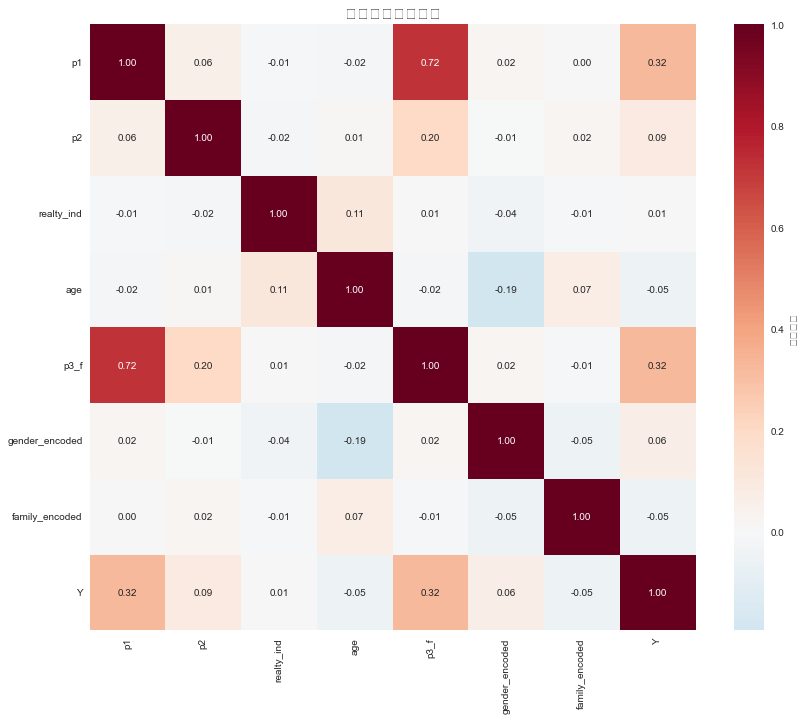


与目标变量Y的相关性（绝对值排序）:
  Y: 1.0000
  p1: 0.3203
  p3_f: 0.3193
  p2: 0.0938
  gender_encoded: 0.0636
  age: 0.0521
  family_encoded: 0.0503


In [9]:
# 特征相关性分析
numeric_features = ['p1', 'p2', 'realty_ind', 'age', 'p3_f', 
                   'gender_encoded', 'family_encoded', 'Y']
correlation_matrix = df_processed[numeric_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'label': '相关系数'})
plt.title('特征相关性热力图', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印与目标变量的相关性
print("\n与目标变量Y的相关性（绝对值排序）:")
target_corr = correlation_matrix['Y'].abs().sort_values(ascending=False)[:-1]
for feature, corr in target_corr.items():
    print(f"  {feature}: {corr:.4f}")

## 4. 模型训练与评估

In [10]:
# 准备特征和目标变量
feature_cols = ['p1', 'p2', 'gender_encoded', 'family_encoded', 
               'realty_ind', 'age', 'p3_f']
X = df_processed[feature_cols].values
y = df_processed['Y'].values

print("="*60)
print("模型训练与评估")
print("="*60)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n数据划分:")
print(f"  训练集: {len(X_train)} 样本 ({len(X_train)/len(X)*100:.1f}%)")
print(f"  测试集: {len(X_test)} 样本 ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n训练集目标分布:")
print(f"  Y=0: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Y=1: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")

模型训练与评估

数据划分:
  训练集: 3240 样本 (80.0%)
  测试集: 810 样本 (20.0%)

训练集目标分布:
  Y=0: 2210 (68.2%)
  Y=1: 1030 (31.8%)


In [11]:
# 定义模型
models = {
    '逻辑回归': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    '决策树': DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    '随机森林': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
}

# 训练并评估模型
results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n训练 {name}...")
    
    # 训练模型
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # 预测
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # 计算指标
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    # 交叉验证
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    metrics['cv_mean'] = cv_scores.mean()
    metrics['cv_std'] = cv_scores.std()
    
    results[name] = metrics
    
    print(f"  ✓ 完成")
    print(f"  准确率: {metrics['accuracy']:.4f}")
    print(f"  AUC: {metrics['auc']:.4f}")
    print(f"  交叉验证: {metrics['cv_mean']:.4f} (+/- {metrics['cv_std']*2:.4f})")


训练 逻辑回归...
  ✓ 完成
  准确率: 0.6617
  AUC: 0.6859
  交叉验证: 0.6824 (+/- 0.0357)

训练 决策树...
  ✓ 完成
  准确率: 0.6568
  AUC: 0.6931
  交叉验证: 0.5926 (+/- 0.0408)

训练 随机森林...
  ✓ 完成
  准确率: 0.6753
  AUC: 0.7002
  交叉验证: 0.6802 (+/- 0.0412)


In [12]:
# 模型对比表格
print("\n" + "="*80)
print("模型性能对比")
print("="*80)

comparison_df = pd.DataFrame({
    '模型': list(results.keys()),
    '准确率': [f"{r['accuracy']:.4f}" for r in results.values()],
    '精确率': [f"{r['precision']:.4f}" for r in results.values()],
    '召回率': [f"{r['recall']:.4f}" for r in results.values()],
    'F1分数': [f"{r['f1']:.4f}" for r in results.values()],
    'AUC': [f"{r['auc']:.4f}" for r in results.values()],
    'CV均值': [f"{r['cv_mean']:.4f}" for r in results.values()]
})

print(comparison_df.to_string(index=False))

# 找出最佳模型
best_model_name = max(results.items(), key=lambda x: x[1]['f1'])[0]
print(f"\n最佳模型（基于F1分数）: {best_model_name}")
print(f"F1分数: {results[best_model_name]['f1']:.4f}")


模型性能对比
  模型    准确率    精确率    召回率   F1分数    AUC   CV均值
逻辑回归 0.6617 0.4669 0.4380 0.4520 0.6859 0.6824
 决策树 0.6568 0.4684 0.5736 0.5157 0.6931 0.5926
随机森林 0.6753 0.4902 0.4845 0.4873 0.7002 0.6802

最佳模型（基于F1分数）: 决策树
F1分数: 0.5157


## 5. 结果可视化

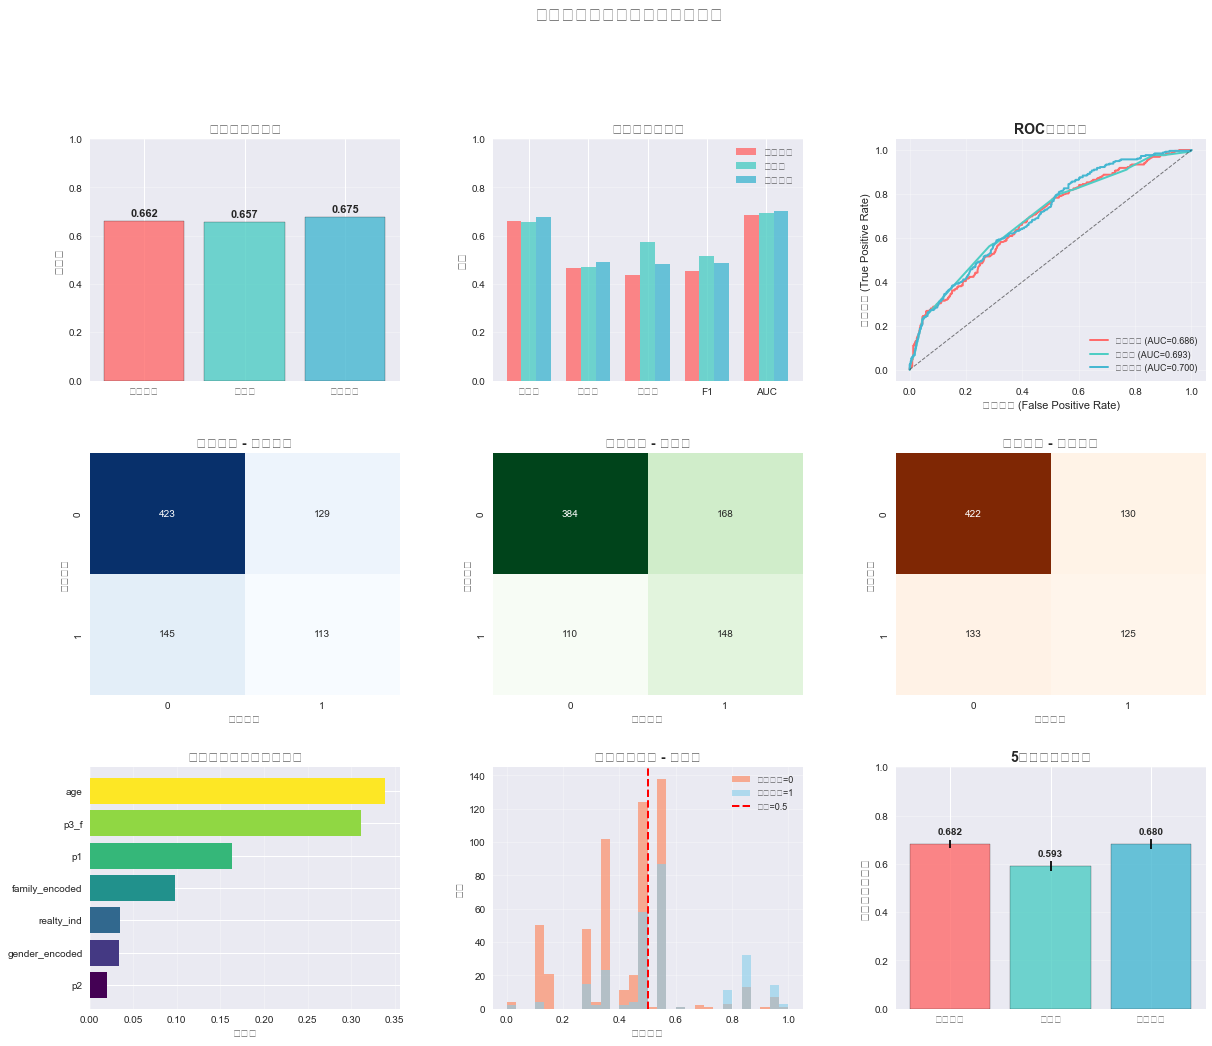

✅ 综合分析图表已生成并保存


In [13]:
# 创建综合可视化图
fig = plt.figure(figsize=(20, 16))

# 创建GridSpec布局
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. 模型性能对比柱状图
ax1 = fig.add_subplot(gs[0, 0])
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
colors_models = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax1.bar(model_names, accuracies, color=colors_models, alpha=0.8, edgecolor='black')
ax1.set_ylabel('准确率', fontsize=12)
ax1.set_title('模型准确率对比', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.3f}', ha='center', fontsize=11, fontweight='bold')

# 2. 多指标雷达图/柱状图
ax2 = fig.add_subplot(gs[0, 1])
metrics_names = ['准确率', '精确率', '召回率', 'F1', 'AUC']
x = np.arange(len(metrics_names))
width = 0.25
for i, (name, res) in enumerate(results.items()):
    values = [res['accuracy'], res['precision'], res['recall'], res['f1'], res['auc']]
    ax2.bar(x + i*width, values, width, label=name, color=colors_models[i], alpha=0.8)
ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics_names, fontsize=10)
ax2.set_ylabel('分数', fontsize=12)
ax2.set_title('多指标性能对比', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

# 3. ROC曲线
ax3 = fig.add_subplot(gs[0, 2])
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax3.plot(fpr, tpr, color=colors_models[i], linewidth=2, 
             label=f"{name} (AUC={res['auc']:.3f})")
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax3.set_xlabel('假阳性率 (False Positive Rate)', fontsize=11)
ax3.set_ylabel('真阳性率 (True Positive Rate)', fontsize=11)
ax3.set_title('ROC曲线对比', fontsize=14, fontweight='bold')
ax3.legend(fontsize=9, loc='lower right')
ax3.grid(alpha=0.3)

# 4. 混淆矩阵 - 逻辑回归
ax4 = fig.add_subplot(gs[1, 0])
cm_lr = confusion_matrix(y_test, results['逻辑回归']['y_pred'])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False)
ax4.set_title('混淆矩阵 - 逻辑回归', fontsize=14, fontweight='bold')
ax4.set_xlabel('预测标签', fontsize=11)
ax4.set_ylabel('真实标签', fontsize=11)
ax4.set_xticklabels(['0', '1'])
ax4.set_yticklabels(['0', '1'])

# 5. 混淆矩阵 - 决策树
ax5 = fig.add_subplot(gs[1, 1])
cm_dt = confusion_matrix(y_test, results['决策树']['y_pred'])
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=ax5, cbar=False)
ax5.set_title('混淆矩阵 - 决策树', fontsize=14, fontweight='bold')
ax5.set_xlabel('预测标签', fontsize=11)
ax5.set_ylabel('真实标签', fontsize=11)
ax5.set_xticklabels(['0', '1'])
ax5.set_yticklabels(['0', '1'])

# 6. 混淆矩阵 - 随机森林
ax6 = fig.add_subplot(gs[1, 2])
cm_rf = confusion_matrix(y_test, results['随机森林']['y_pred'])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=ax6, cbar=False)
ax6.set_title('混淆矩阵 - 随机森林', fontsize=14, fontweight='bold')
ax6.set_xlabel('预测标签', fontsize=11)
ax6.set_ylabel('真实标签', fontsize=11)
ax6.set_xticklabels(['0', '1'])
ax6.set_yticklabels(['0', '1'])

# 7. 特征重要性（随机森林）
ax7 = fig.add_subplot(gs[2, 0])
rf_model = trained_models['随机森林']
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)
colors_feat = plt.cm.viridis(np.linspace(0, 1, len(feature_cols)))
ax7.barh(importance_df['feature'], importance_df['importance'], color=colors_feat)
ax7.set_xlabel('重要性', fontsize=11)
ax7.set_title('特征重要性（随机森林）', fontsize=14, fontweight='bold')
ax7.grid(axis='x', alpha=0.3)

# 8. 预测概率分布
ax8 = fig.add_subplot(gs[2, 1])
best_pred = results[best_model_name]['y_prob']
ax8.hist(best_pred[y_test==0], bins=30, alpha=0.6, label='真实标签=0', color='coral')
ax8.hist(best_pred[y_test==1], bins=30, alpha=0.6, label='真实标签=1', color='skyblue')
ax8.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='阈值=0.5')
ax8.set_xlabel('预测概率', fontsize=11)
ax8.set_ylabel('频数', fontsize=11)
ax8.set_title(f'预测概率分布 - {best_model_name}', fontsize=14, fontweight='bold')
ax8.legend(fontsize=9)
ax8.grid(alpha=0.3)

# 9. 交叉验证分数
ax9 = fig.add_subplot(gs[2, 2])
cv_means = [results[m]['cv_mean'] for m in model_names]
cv_stds = [results[m]['cv_std'] for m in model_names]
bars = ax9.bar(model_names, cv_means, yerr=cv_stds, color=colors_models, 
               alpha=0.8, capsize=5, edgecolor='black')
ax9.set_ylabel('交叉验证准确率', fontsize=12)
ax9.set_title('5折交叉验证结果', fontsize=14, fontweight='bold')
ax9.set_ylim(0, 1)
ax9.grid(axis='y', alpha=0.3)
for bar, mean, std in zip(bars, cv_means, cv_stds):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02, 
             f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('机器学习分类模型分析结果总览', fontsize=18, fontweight='bold', y=0.995)
plt.savefig('ml_analysis_results.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ 综合分析图表已生成并保存")

## 6. 详细分类报告

In [14]:
# 输出最佳模型的详细分类报告
print("="*60)
print(f"详细分类报告 - {best_model_name}")
print("="*60)

best_predictions = results[best_model_name]['y_pred']
print(classification_report(y_test, best_predictions, 
                           target_names=['Class 0', 'Class 1']))

# 计算其他指标
tn, fp, fn, tp = confusion_matrix(y_test, best_predictions).ravel()
specificity = tn / (tn + fp)  # 特异度
sensitivity = tp / (tp + fn)  # 敏感度（召回率）

print(f"\n其他指标:")
print(f"  特异度 (Specificity): {specificity:.4f}")
print(f"  敏感度 (Sensitivity): {sensitivity:.4f}")
print(f"  真阴性: {tn}, 假阳性: {fp}, 假阴性: {fn}, 真阳性: {tp}")

详细分类报告 - 决策树
              precision    recall  f1-score   support

     Class 0       0.78      0.70      0.73       552
     Class 1       0.47      0.57      0.52       258

    accuracy                           0.66       810
   macro avg       0.62      0.63      0.62       810
weighted avg       0.68      0.66      0.66       810


其他指标:
  特异度 (Specificity): 0.6957
  敏感度 (Sensitivity): 0.5736
  真阴性: 384, 假阳性: 168, 假阴性: 110, 真阳性: 148


## 7. 模型可解释性分析

In [15]:
# 特征重要性详细分析
print("="*60)
print("特征重要性分析 - 随机森林")
print("="*60)

feature_importance = pd.DataFrame({
    '特征名': feature_cols,
    '重要性': rf_model.feature_importances_,
    '重要性%': rf_model.feature_importances_ * 100
}).sort_values('重要性', ascending=False)

print("\n特征重要性排序:")
print(feature_importance.to_string(index=False))

# 逻辑回归系数
print("\n" + "="*60)
print("逻辑回归系数分析")
print("="*60)

lr_model = trained_models['逻辑回归']
lr_coef = pd.DataFrame({
    '特征名': feature_cols,
    '系数': lr_model.coef_[0],
    '影响': ['正向' if c > 0 else '负向' for c in lr_model.coef_[0]]
}).sort_values('系数', ascending=False)

print(lr_coef.to_string(index=False))
print(f"\n截距 (Intercept): {lr_model.intercept_[0]:.4f}")

特征重要性分析 - 随机森林

特征重要性排序:
           特征名      重要性      重要性%
           age 0.338661 33.866113
          p3_f 0.311285 31.128494
            p1 0.163532 16.353204
family_encoded 0.097871  9.787128
    realty_ind 0.034668  3.466797
gender_encoded 0.033615  3.361490
            p2 0.020368  2.036774

逻辑回归系数分析
           特征名        系数 影响
            p1  1.177351 正向
            p2  0.957652 正向
gender_encoded  0.255301 正向
    realty_ind  0.092006 正向
          p3_f  0.065485 正向
           age -0.009538 负向
family_encoded -0.150484 负向

截距 (Intercept): -1.1569


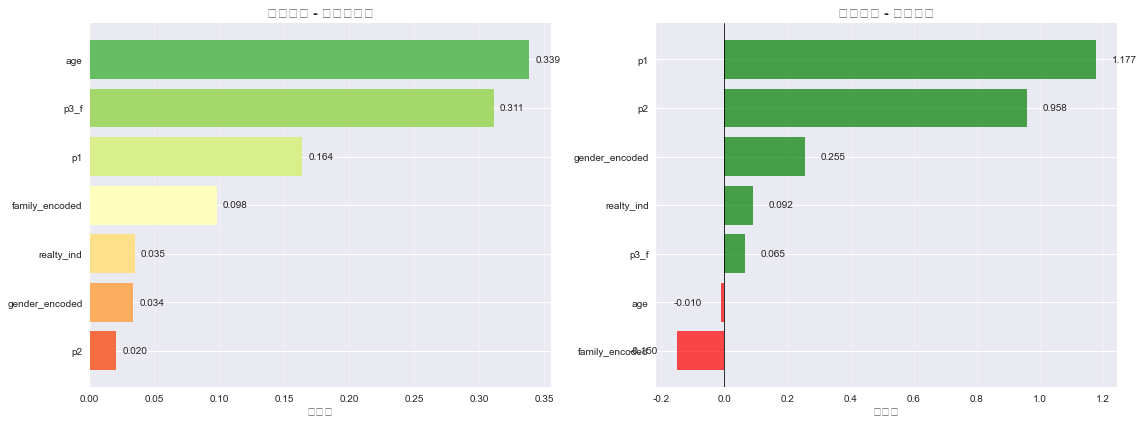

In [16]:
# 可视化特征重要性对比
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 随机森林特征重要性
ax1 = axes[0]
importance_sorted = feature_importance.sort_values('重要性', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feature_cols)))
bars = ax1.barh(importance_sorted['特征名'], importance_sorted['重要性'], color=colors)
ax1.set_xlabel('重要性', fontsize=12)
ax1.set_title('随机森林 - 特征重要性', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, importance_sorted['重要性'])):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=10)

# 逻辑回归系数
ax2 = axes[1]
lr_coef_sorted = lr_coef.sort_values('系数', ascending=True)
colors_lr = ['red' if c < 0 else 'green' for c in lr_coef_sorted['系数']]
bars2 = ax2.barh(lr_coef_sorted['特征名'], lr_coef_sorted['系数'], color=colors_lr, alpha=0.7)
ax2.set_xlabel('系数值', fontsize=12)
ax2.set_title('逻辑回归 - 特征系数', fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars2, lr_coef_sorted['系数'])):
    offset = 0.05 if val > 0 else -0.15
    ax2.text(val + offset, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 业务洞察与结论

In [17]:
# 生成分析报告
print("="*70)
print("机器学习分类分析 - 业务洞察报告")
print("="*70)

print(f"\n📊 数据概况:")
print(f"   • 总样本数: {len(df):,}")
print(f"   • 特征数量: {len(feature_cols)}")
print(f"   • 目标变量分布: Y=0 ({sum(df['Y']==0)/len(df)*100:.1f}%), Y=1 ({sum(df['Y']==1)/len(df)*100:.1f}%)")

print(f"\n🏆 最佳模型: {best_model_name}")
print(f"   • 准确率: {results[best_model_name]['accuracy']:.2%}")
print(f"   • F1分数: {results[best_model_name]['f1']:.4f}")
print(f"   • AUC: {results[best_model_name]['auc']:.4f}")

print(f"\n🔍 关键发现:")

# 最重要的3个特征
top3_features = feature_importance.head(3)['特征名'].tolist()
print(f"   • 最重要的3个特征: {', '.join(top3_features)}")

# 年龄分析
age_group_analysis = df_processed.groupby('age_group')['Y'].mean().sort_values(ascending=False)
print(f"   • 目标变量比例最高的年龄组: {age_group_analysis.index[0]} ({age_group_analysis.iloc[0]:.2%})")

# 性别分析
gender_analysis = df_processed.groupby('gender')['Y'].mean()
higher_gender = gender_analysis.idxmax()
print(f"   • {higher_gender}性目标变量比例更高 ({gender_analysis.max():.2%} vs {gender_analysis.min():.2%})")

# 房产分析
realty_analysis = df_processed.groupby('realty_ind')['Y'].mean()
print(f"   • 有房产者目标变量比例: {realty_analysis[1]:.2%}")
print(f"   • 无房产者目标变量比例: {realty_analysis[0]:.2%}")

print(f"\n💡 建议:")
print(f"   1. 重点关注特征: {top3_features[0]}、{top3_features[1]}、{top3_features[2]}")
print(f"   2. 针对{higher_gender}性群体制定针对性策略")
print(f"   3. 年龄组{age_group_analysis.index[0]}是重点目标人群")
print(f"   4. 模型可用于预测，建议定期重训练以保持准确性")

print("\n" + "="*70)
print("分析完成！所有图表已保存。")
print("="*70)

机器学习分类分析 - 业务洞察报告

📊 数据概况:
   • 总样本数: 4,050
   • 特征数量: 7
   • 目标变量分布: Y=0 (68.2%), Y=1 (31.8%)

🏆 最佳模型: 决策树
   • 准确率: 65.68%
   • F1分数: 0.5157
   • AUC: 0.6931

🔍 关键发现:
   • 最重要的3个特征: age, p3_f, p1
   • 目标变量比例最高的年龄组: 30-40 (34.74%)
   • M性目标变量比例更高 (35.90% vs 29.67%)
   • 有房产者目标变量比例: 32.04%
   • 无房产者目标变量比例: 31.27%

💡 建议:
   1. 重点关注特征: age、p3_f、p1
   2. 针对M性群体制定针对性策略
   3. 年龄组30-40是重点目标人群
   4. 模型可用于预测，建议定期重训练以保持准确性

分析完成！所有图表已保存。


---

## 📁 生成的文件

本Notebook运行后会生成以下文件：
- `eda_overview.png` - 探索性数据分析综合图
- `correlation_heatmap.png` - 特征相关性热力图
- `ml_analysis_results.png` - 机器学习分析结果总览（9宫格）
- `feature_importance_analysis.png` - 特征重要性对比分析

## 📝 总结

本Notebook演示了完整的机器学习数据分析流程：
1. **数据加载与清洗** - 数据质量检查和预处理
2. **探索性数据分析** - 统计摘要和可视化
3. **特征工程** - 编码、分箱和交互特征
4. **模型训练** - 3种分类算法对比
5. **模型评估** - 多维度指标和交叉验证
6. **结果可视化** - 9宫格综合展示
7. **可解释性分析** - 特征重要性和系数解读
8. **业务洞察** - 结合业务场景的建议